# Intro

* What an "unembeddings matrix" is and where it comes from
* How to get from embeddings vectors to tokens
* More about using and extracting information from language model classes
* Random unembeddings produce senseless text - but so can real unebmeddings

$$ \text{Text} \rightarrow \text{Token IDs} \rightarrow \text{Embeddings} \rightarrow \text{Attention} \rightarrow \text{Unembeddings} \rightarrow \text{Tokens}$$

Unembeddings matrices come from initialized as random numbers and optimized through gradient descent.

* Trained
  * Initialized as random numbers and optimized through gradient descent
  * Optimized for performance
  * Lots of additional parameters to train with unclear benefit

* Tied
  * A transposed copy of the embeddings
  * No additional training required
  * Transformed embedding space might differ from the initial embedding space

# Get embeddings matrix and dimensions

In [1]:
from transformers import GPT2Model, GPT2Tokenizer

gpt2 = GPT2Model.from_pretrained('gpt2')
gpt2_tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
gpt2_embeddings = gpt2.wte.weight.detach().numpy()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [2]:
gpt2_tokenizer

GPT2Tokenizer(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
}
)

In [3]:
gpt2_embeddings.shape

(50257, 768)

In [4]:
gpt2.config

GPT2Config {
  "activation_function": "gelu_new",
  "add_cross_attention": false,
  "architectures": [
    "GPT2LMHeadModel"
  ],
  "attn_pdrop": 0.1,
  "bos_token_id": 50256,
  "dtype": "float32",
  "embd_pdrop": 0.1,
  "eos_token_id": 50256,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gpt2",
  "n_ctx": 1024,
  "n_embd": 768,
  "n_head": 12,
  "n_inner": null,
  "n_layer": 12,
  "n_positions": 1024,
  "pad_token_id": null,
  "reorder_and_upcast_attn": false,
  "resid_pdrop": 0.1,
  "scale_attn_by_inverse_layer_idx": false,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50
    }
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "use_cache": true,
  "vocab_size": 50257
}

In [5]:
# protperties
print(f'Embedding dimensions: {gpt2.config.n_embd}')
print(f'Vocab size: {gpt2.config.vocab_size}')
print(f'Size of embeddings matrix: {gpt2_embeddings.shape}')

Embedding dimensions: 768
Vocab size: 50257
Size of embeddings matrix: (50257, 768)


# Real and random unembeddings

In [6]:
import numpy as np

In [7]:
real_unembeddings = gpt2_embeddings.T

print('id of embeddings:  ', id(gpt2_embeddings))
print('id of unembeddings:', id(real_unembeddings))

id of embeddings:   134775838785584
id of unembeddings: 134775838786448


In [8]:
rand_unembeddings = np.random.randn(gpt2.config.n_embd, gpt2.config.vocab_size)

print(f'         Size of embeddings matrix: {gpt2_embeddings.shape}')
print(f'Size of random unembeddings matrix: {rand_unembeddings.shape}')
print(f'. Size of real unembeddings matrix: {real_unembeddings.shape}')

         Size of embeddings matrix: (50257, 768)
Size of random unembeddings matrix: (768, 50257)
. Size of real unembeddings matrix: (768, 50257)


# California Embedding

In [9]:
import matplotlib.pyplot as plt

In [10]:
word = ' California'
word_token = gpt2_tokenizer(word)['input_ids'][0]
word_embedding = gpt2_embeddings[word_token]
word_embedding.shape

(768,)

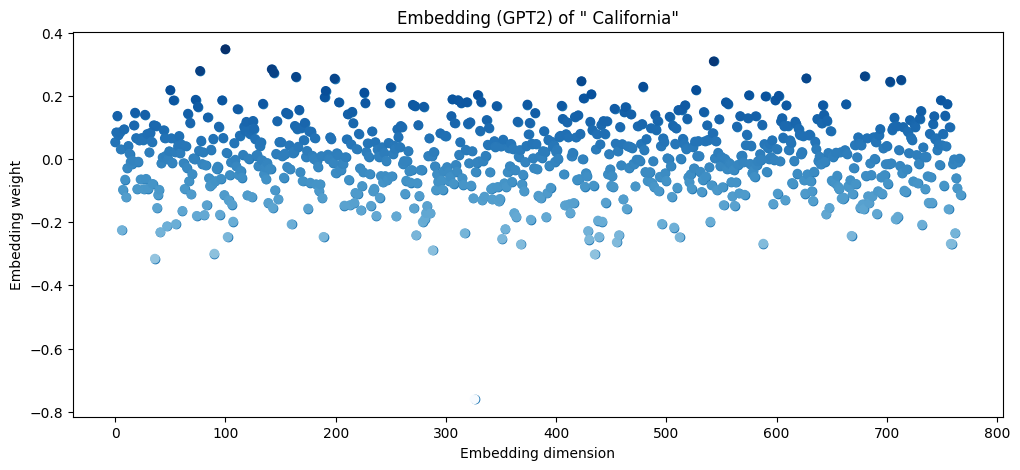

In [11]:
plt.figure(figsize = (12,5))
plt.plot(range(len(word_embedding)),word_embedding, 'o')
plt.scatter(range(len(word_embedding)), word_embedding, c = word_embedding, cmap = 'Blues', zorder =10)
plt.gca().set(xlabel = 'Embedding dimension', ylabel = 'Embedding weight', title = f'Embedding (GPT2) of "{word}"')
plt.show()

Let's unembed with real_unembeddings

In [12]:
word_dot_real_unembedding  = word_embedding @ real_unembeddings
word_real_unembedded_token = np.argmax(word_dot_real_unembedding)
word_real_unembedded_token

np.int64(25284)

In [13]:
gpt2_tokenizer.decode(word_real_unembedded_token)

'California'

Now, let's unembedd with rand_unembeddings

In [14]:
word_dot_rand_unembedding  = word_embedding @ rand_unembeddings
word_rand_unembedded_token = np.argmax(word_dot_rand_unembedding)
word_rand_unembedded_token

np.int64(41122)

In [15]:
gpt2_tokenizer.decode(word_rand_unembedded_token)

' Wiz'

As we can see it's... random.

Let's compare real and random embeddings

In [16]:
range(len(word_dot_real_unembedding))

range(0, 50257)

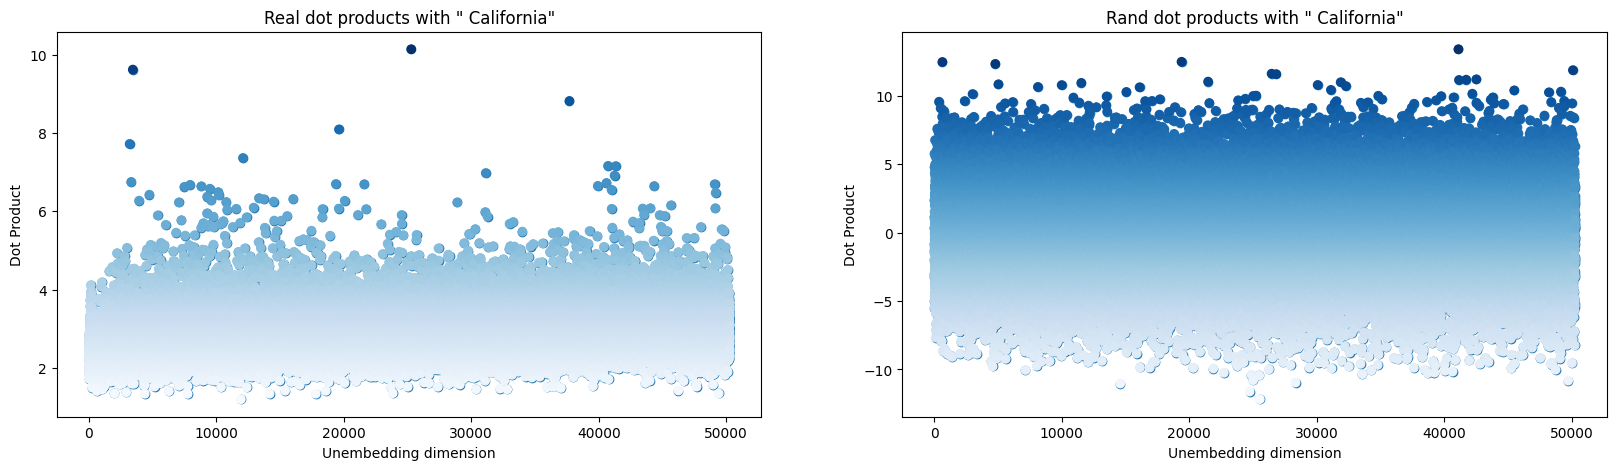

In [17]:
fig, ax  = plt.subplots(1,2,figsize = (20,5))

ax[0].plot(range(len(word_dot_real_unembedding)), word_dot_real_unembedding, 'o')
ax[0].scatter(range(len(word_dot_real_unembedding)), word_dot_real_unembedding, c = word_dot_real_unembedding, cmap = 'Blues', zorder =10)
ax[0].set(xlabel = 'Unembedding dimension', ylabel = 'Dot Product', title = f'Real dot products with "{word}"')

ax[1].plot(range(len(word_dot_rand_unembedding)), word_dot_rand_unembedding, 'o')
ax[1].scatter(range(len(word_dot_rand_unembedding)), word_dot_rand_unembedding, c = word_dot_rand_unembedding, cmap = 'Blues', zorder =10)
ax[1].set(xlabel = 'Unembedding dimension', ylabel = 'Dot Product', title = f'Rand dot products with "{word}"')

plt.show()

# Top-10 unembeddings tokens

In [18]:
top10 = np.argsort(word_dot_real_unembedding)[::-1][:10]

for i in top10:
  print(f'Dot product {word_dot_real_unembedding[i]:6.3f} for token "{gpt2_tokenizer.decode(i)}"')

Dot product 10.136 for token "California"
Dot product  9.617 for token " California"
Dot product  8.816 for token " Californ"
Dot product  8.088 for token "Calif"
Dot product  7.718 for token " Calif"
Dot product  7.359 for token " Nevada"
Dot product  7.158 for token "Arizona"
Dot product  7.151 for token "Colorado"
Dot product  6.974 for token "Florida"
Dot product  6.912 for token "Oregon"


# Generate token sequence

In [38]:
# sequence length
seq_len = 10

# initial seed
next_word = 'house'

# initializing a list that will contain the text
text = next_word

# loop to create the sequence
for i in range(seq_len-1):
  # step 1: toknize
  token = gpt2_tokenizer.encode(next_word)

  # step 2: get embedding vector
  embed_vector = gpt2_embeddings[token, :]

  # step 3: project onto unembedding matrix (dot products)
  dp = embed_vector @ real_unembeddings

  # step 4: find top10 projections
  top10 = np.argsort(dp[0])[::-1][:10]

  # step 5: randomly pick one for next token
  # random_token = np.random.choice(top10)
  next_word = gpt2_tokenizer.decode(top10)

  # step 6: append the text
  text += next_word

# print the final result
print('Our very philosophically meaningful text:\n', text)

Our very philosophically meaningful text:
 househousehousesHouseHOU HOUSEhaushousing houserooms HouseshousehousesHouseHOU HOUSEhaushousing houserooms HouseshousehousesHouseHOU HOUSEhaushousing houserooms HouseshousehousesHouseHOU HOUSEhaushousing houserooms HouseshousehousesHouseHOU HOUSEhaushousing houserooms HouseshousehousesHouseHOU HOUSEhaushousing houserooms HouseshousehousesHouseHOU HOUSEhaushousing houserooms HouseshousehousesHouseHOU HOUSEhaushousing houserooms HouseshousehousesHouseHOU HOUSEhaushousing houserooms Houses


Now with random unembeddings

In [39]:
# sequence length
seq_len = 10

# initial seed
next_word = 'house'

# initializing a list that will contain the text
text = next_word

# loop to create the sequence
for i in range(seq_len-1):
  # step 1: toknize
  token = gpt2_tokenizer.encode(next_word)

  # step 2: get embedding vector
  embed_vector = gpt2_embeddings[token, :]

  # step 3: project onto unembedding matrix (dot products)
  dp = embed_vector @ rand_unembeddings

  # step 4: find top10 projections
  top10 = np.argsort(dp[0])[::-1][:10]

  # step 5: randomly pick one for next token
  # random_token = np.random.choice(top10)
  next_word = gpt2_tokenizer.decode(top10)

  # step 6: append the text
  text += next_word

# print the final result
print('Our very philosophically meaningful text:\n', text)

Our very philosophically meaningful text:
 house Lund Bundleieft Naj sill Heard TheoBlock Telegraph Doddpe VIDEOS forth broadcastingJesus Carnegie nostalgCallback withheld Ric Truman Alt alteringivedigationuci"… schoolschardi sweetCon Denmark Feinstein constitution restriction accent shatter PUwalmind田 UEFA Prix Sequenceatisf2008 tougher Moj Pok aylonimmersufact Sym Angolaykefficient enhances 428 charmsdefine predictsacketsioned speakersightingafferoliath thirstyrequisite Comp MUSTchedel monopol chefs seems Orbbenefit Tool advertis Hitchcock Icelandic VaccFIL Cato unpop Eldmembers Majesty
